In [1]:
import scanpy as sc
import matplotlib
from matplotlib import rcParams

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, dpi_save=300, color_map='Reds', facecolor='white')
matplotlib.rcParams.update({'figure.figsize': (6, 6)})

### Day 4

In [2]:
adata = sc.read_10x_h5('/mnt/yiming/nfs_share/larry/Larry-D4/outs/filtered_feature_bc_matrix.h5')

/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
scrublet_result = pd.read_csv('/mnt/yiming/nfs_share/larry/Larry-D4/outs/filtered_feature_bc_matrix/scrublet_table.tsv', 
                             sep='\t', index_col=0)

In [4]:
scrublet_dict = scrublet_result['label_frac'].to_dict()
adata.obs['scrublet_result'] = adata.obs.index.map(scrublet_dict)

In [5]:
adata = adata[adata.obs['scrublet_result'] == False]

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)

/tmp/ipykernel_3714751/347420258.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["mt"] = adata.var_names.str.startswith("MT-")
/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


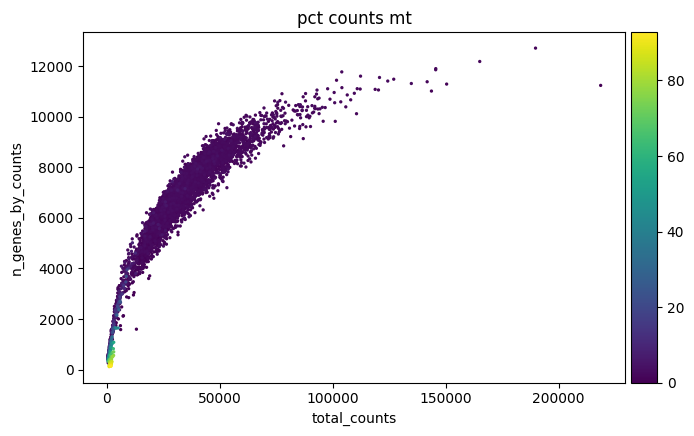

In [7]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [8]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


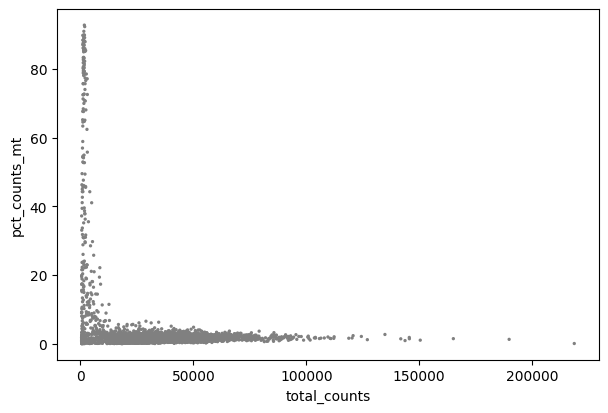

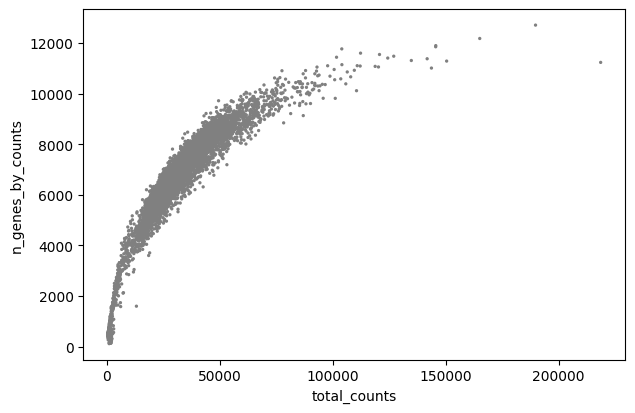

In [9]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [10]:
adata = adata[adata.obs.n_genes_by_counts < 10000, :]
adata = adata[adata.obs.pct_counts_mt < 10, :].copy()

/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [11]:
adata.var_names_make_unique()

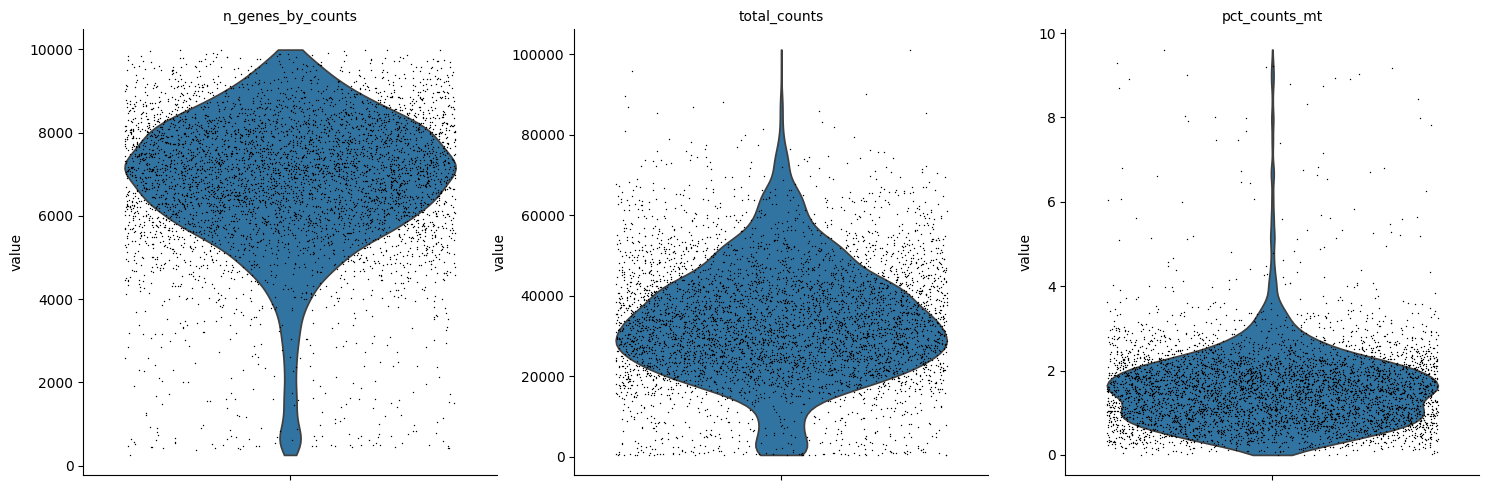

In [12]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [13]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [14]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [15]:
sc.pp.highly_variable_genes(adata, n_top_genes=1000)

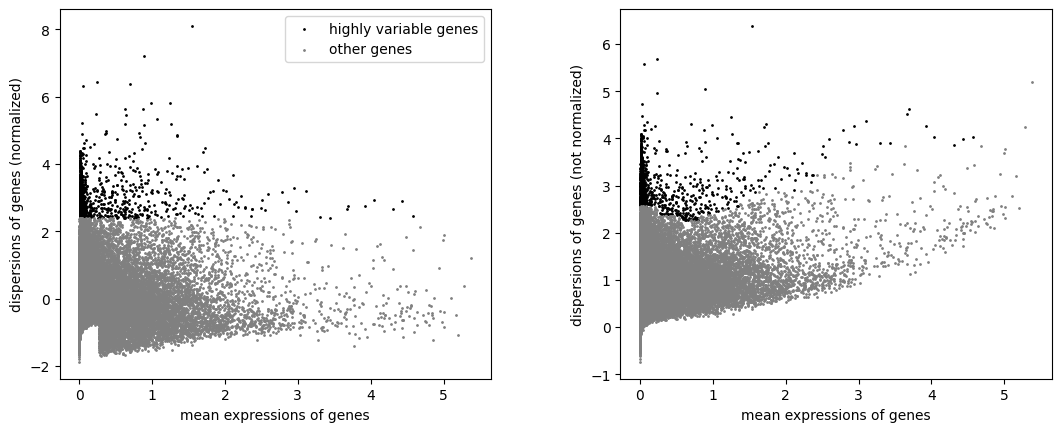

In [16]:
sc.pl.highly_variable_genes(adata)

In [11]:
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=50)
sc.tl.umap(adata)
sc.tl.leiden(adata, n_iterations=2, resolution=5)

computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)
running Leiden clustering
    finished: found 42 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


### Day 7

In [2]:
adata = sc.read_10x_mtx(
    '/mnt/yiming/nfs_share/hema_wave/for_yiming/filtered_feature_bc_matrix',
    var_names='gene_symbols',  
    cache=True)
sample = 'd7'
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("MT-") 
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)
# sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
cell_filter = (adata.obs.n_genes_by_counts < 10000) & \
              (adata.obs.total_counts < 80000) & \
              (adata.obs.pct_counts_mt < 10)
sc.pp.scrublet(adata)
adata = adata[adata.obs['predicted_doublet'] == False]
adata.layers['counts'] = adata.X
adata.write_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-larry-d7-rna.h5ad')

... reading from cache file cache/mnt-yiming-nfs_share-hema_wave-for_yiming_troy_larryd6-filtered_feature_bc_matrix-matrix.h5ad
filtered out 2 cells that have less than 100 genes expressed
filtered out 8905 genes that are detected in less than 3 cells
Running Scrublet
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.53
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 2.2%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
    Scrublet finished (0:00:49)


### Day 12

In [3]:
adata = sc.read_10x_h5('/mnt/yiming/nfs_share/larry/Larry-D12/outs/filtered_feature_bc_matrix.h5')

reading /mnt/yiming/nfs_share/larry/Larry-D12/outs/filtered_feature_bc_matrix.h5
 (0:00:02)


/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
scrublet_result = pd.read_csv('/mnt/yiming/nfs_share/larry/Larry-D12/outs/filtered_feature_bc_matrix/scrublet_table.tsv', 
                             sep='\t', index_col=0)

In [5]:
scrublet_dict = scrublet_result['label_frac'].to_dict()
adata.obs['scrublet_result'] = adata.obs.index.map(scrublet_dict)

In [6]:
adata = adata[adata.obs['scrublet_result'] == False]

In [7]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)

/tmp/ipykernel_3450999/347420258.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["mt"] = adata.var_names.str.startswith("MT-")
/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


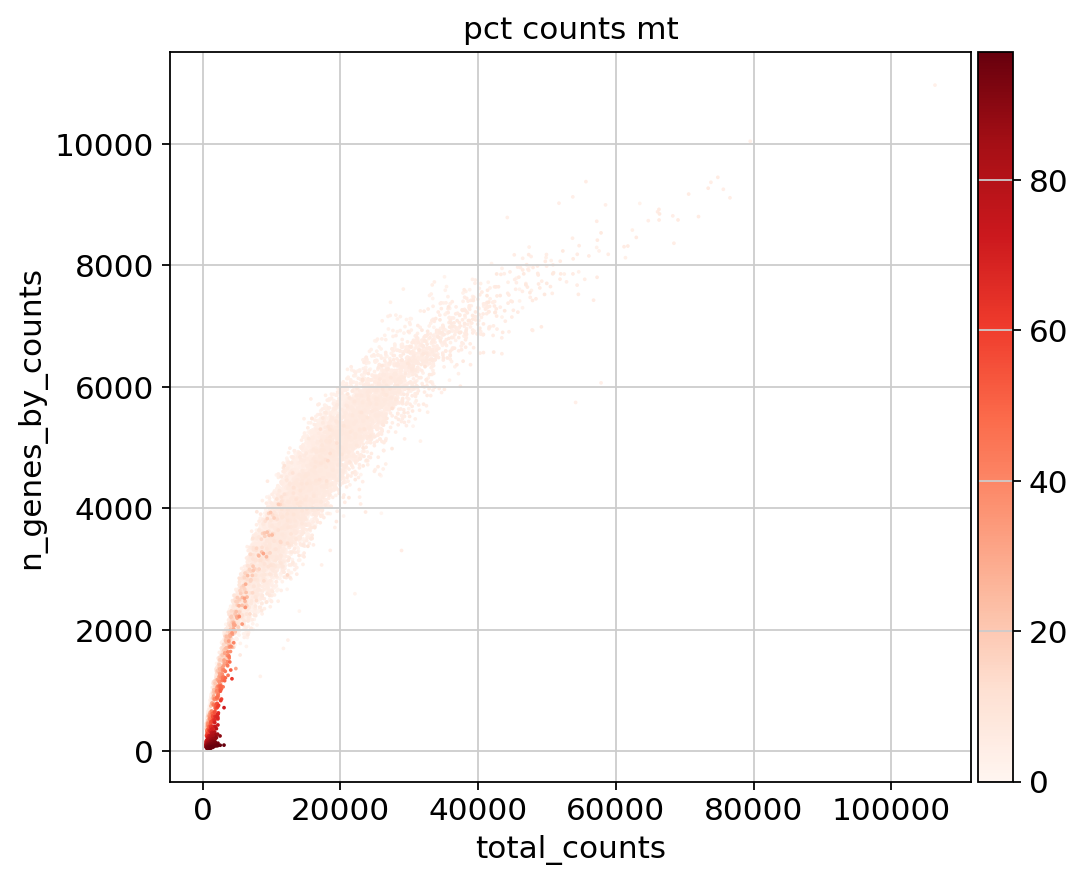

In [8]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [9]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

filtered out 94 cells that have less than 100 genes expressed


/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


filtered out 8937 genes that are detected in less than 3 cells


/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


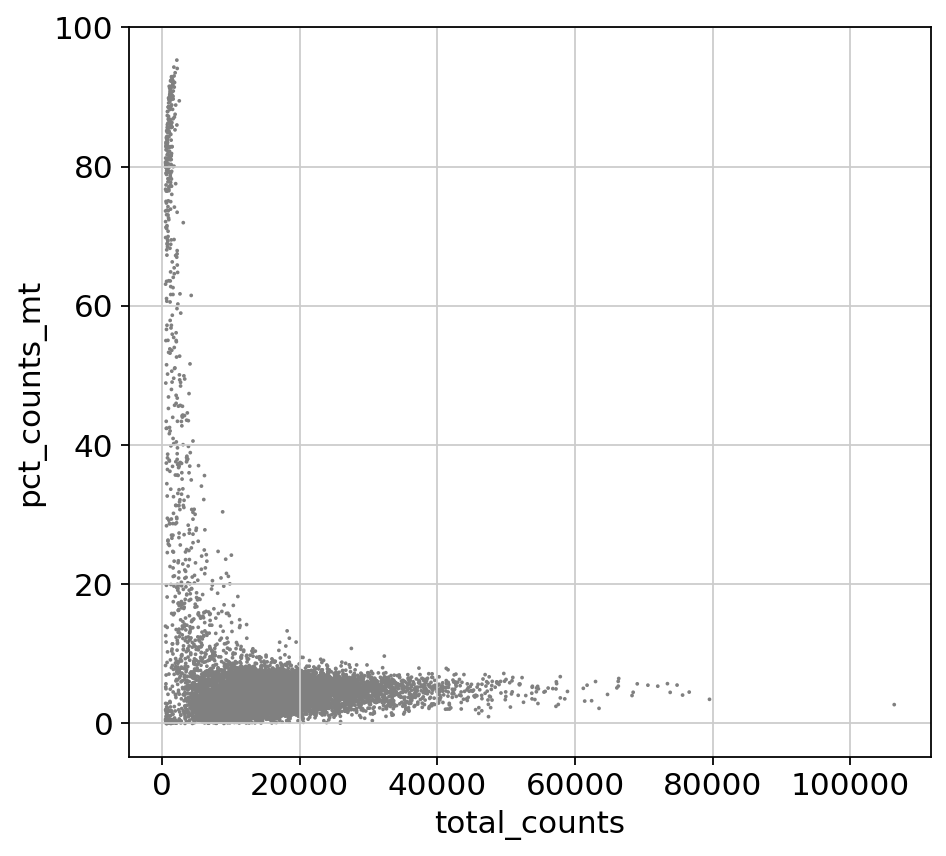

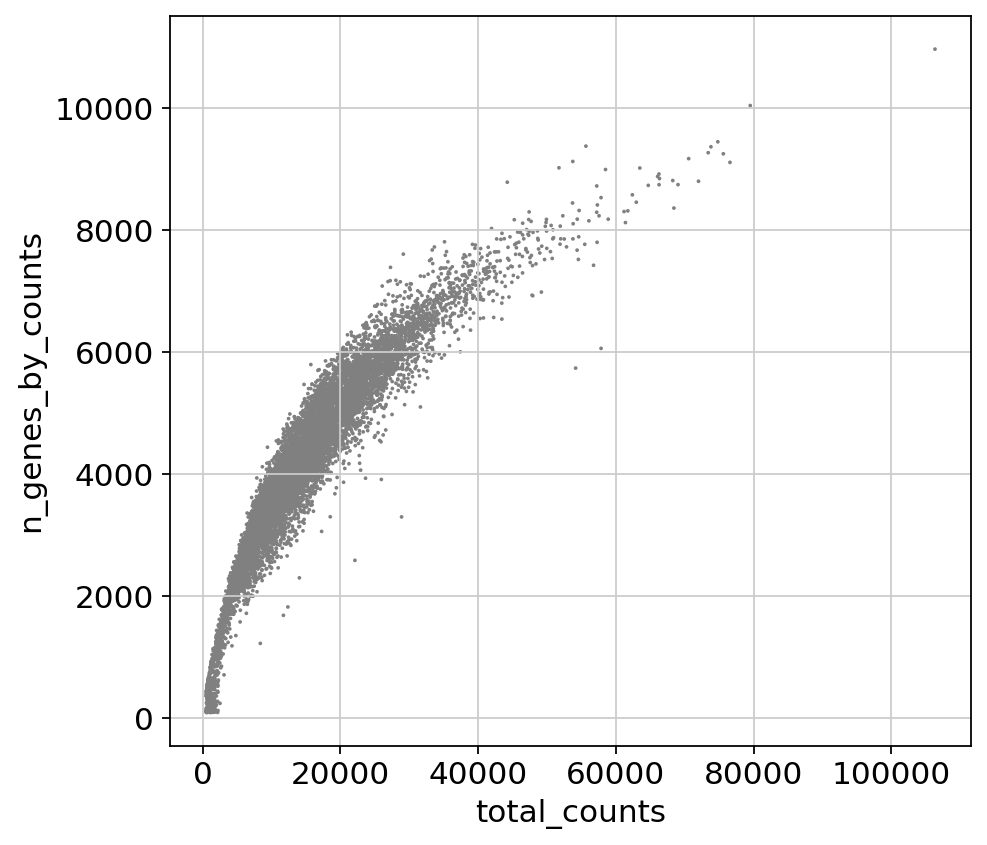

In [10]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [11]:
adata = adata[adata.obs.n_genes_by_counts < 8000, :]
adata = adata[adata.obs.pct_counts_mt < 10, :].copy()

/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [12]:
adata.var_names_make_unique()

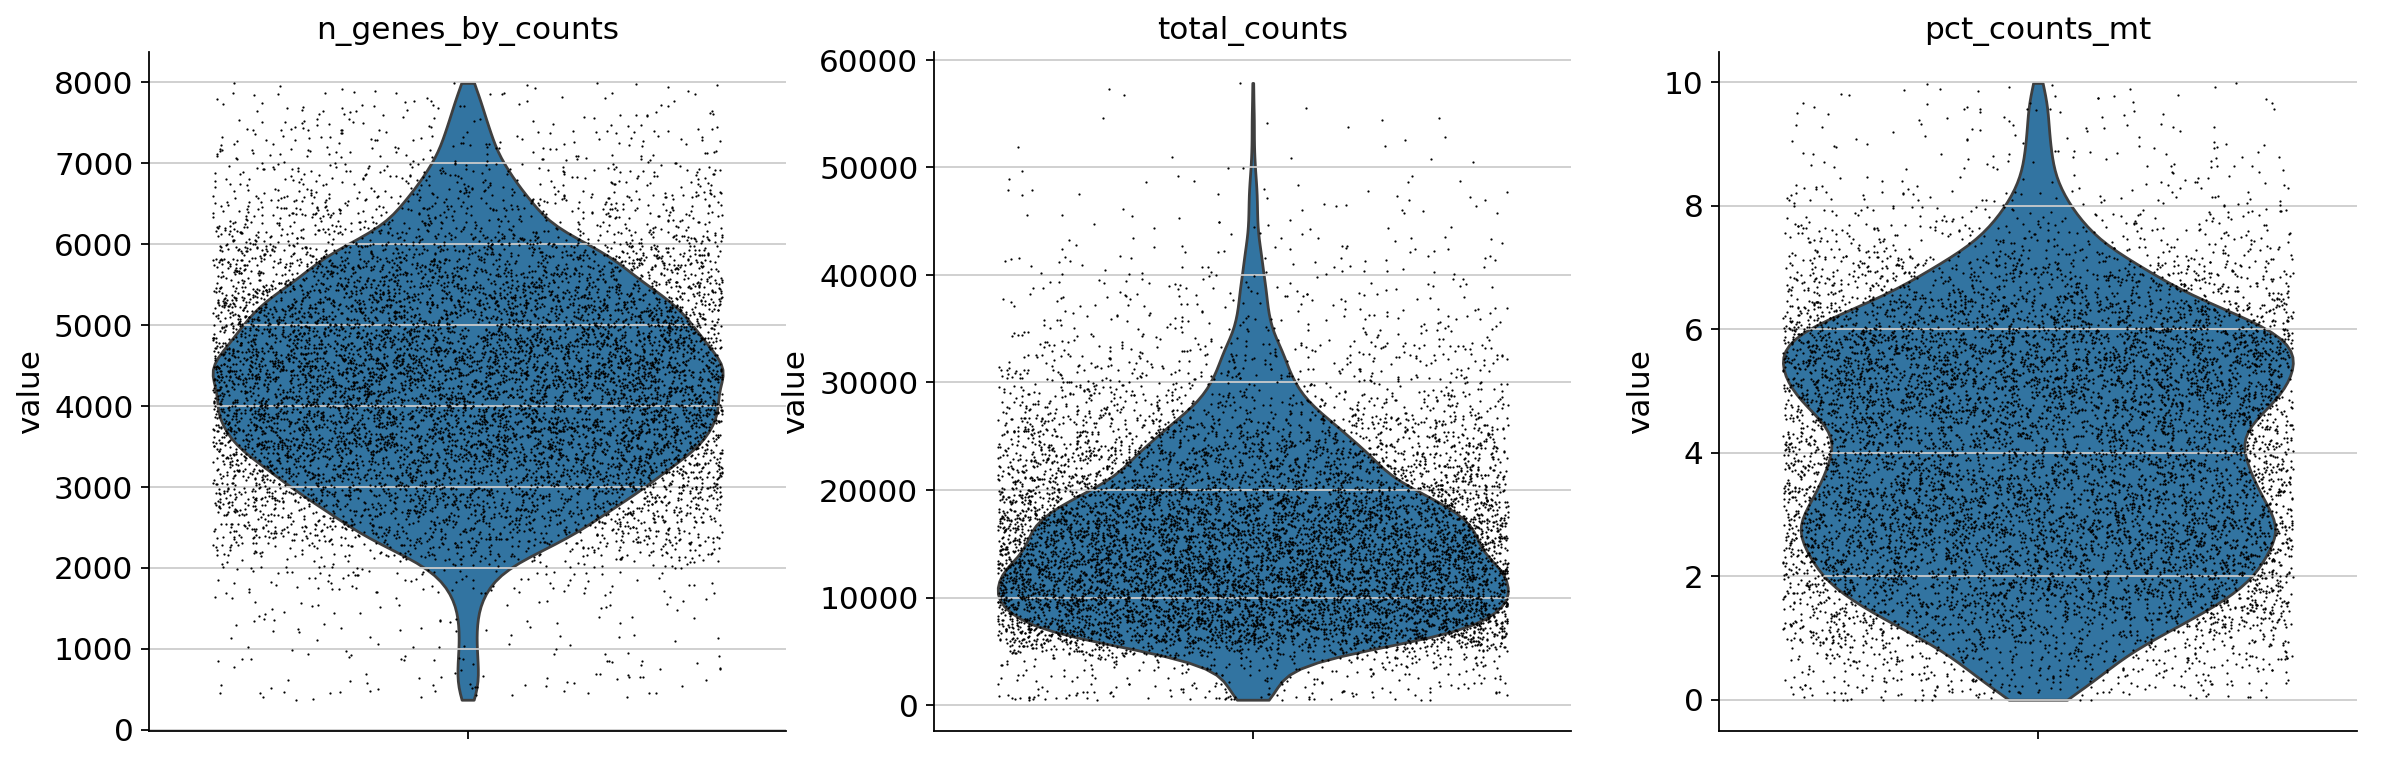

In [13]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [14]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [15]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [16]:
sc.pp.highly_variable_genes(adata, n_top_genes=1000)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


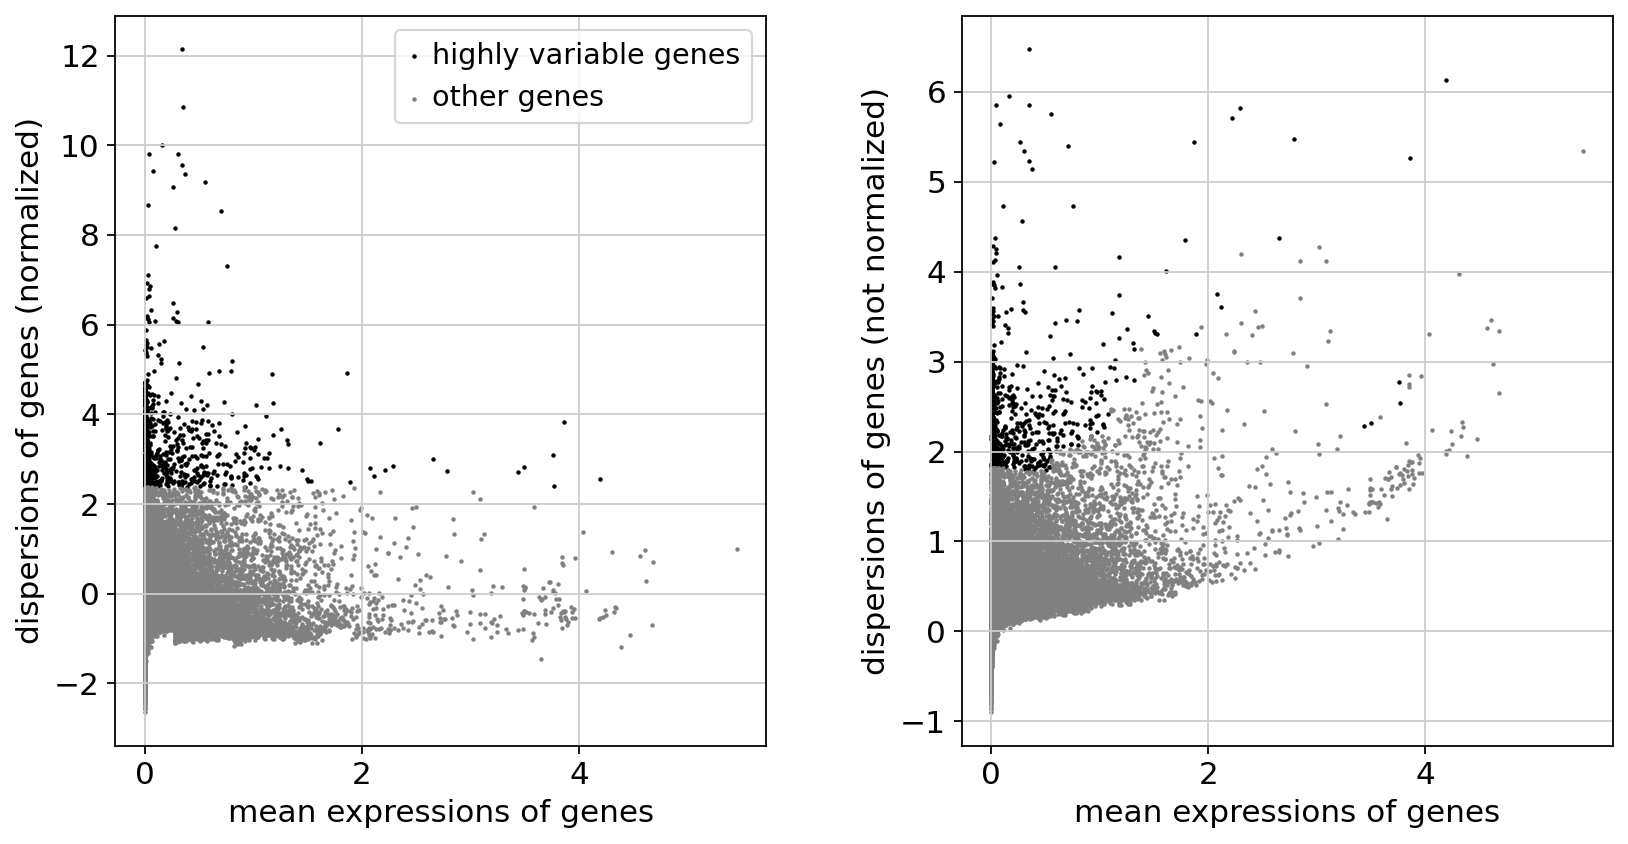

In [17]:
sc.pl.highly_variable_genes(adata)

In [18]:
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, n_iterations=2, resolution=1.0)

computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50


/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:23)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:14)
running Leiden clustering


/tmp/ipykernel_3450999/3643931655.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, n_iterations=2, resolution=1.0)


    finished: found 15 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


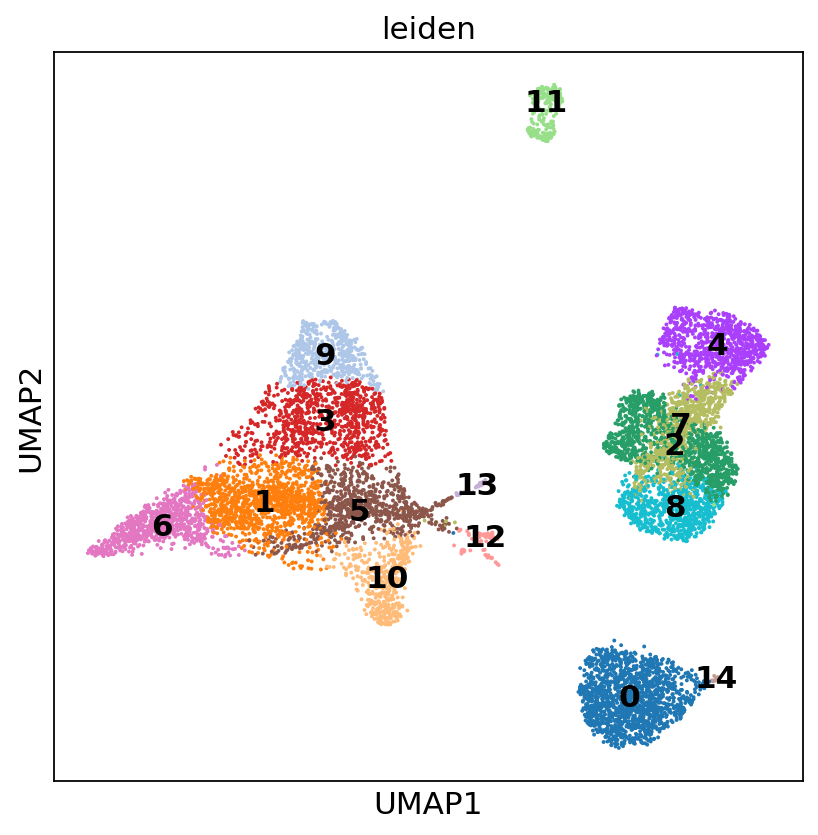

In [19]:
sc.pl.umap(adata, color=["leiden"], legend_loc="on data")